In [74]:
import torch
import torchvision
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from torchvision.models.detection import maskrcnn_resnet50_fpn

In [75]:
img_path = "img12.JPG"

In [76]:
# ---------- Load Segmentation Model ----------

model = maskrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None
)

in_features = model.roi_heads.box_predictor.cls_score.in_features

mask_in_features = model.roi_heads.mask_predictor.conv5_mask.in_channels

model.roi_heads.box_predictor = (
    torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features,
        2
    )
)

model.roi_heads.mask_predictor = (
    torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
        mask_in_features,
        256,
        2
    )
)

model.load_state_dict(
    torch.load("leaf_maskrcnn.pth")
)

model.eval()

print("Segmentation Model Loaded")

Segmentation Model Loaded


In [77]:
# ---------- Load Classification Model ----------

classifier = load_model(
    r"E:\small_inception_model\small_inception_model.keras"
)

print("Classification Model Loaded")

Classification Model Loaded


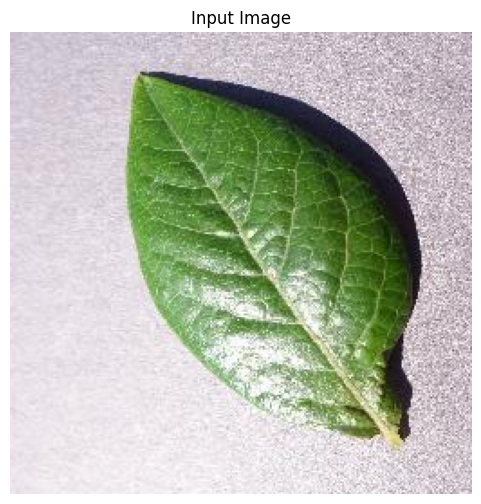

In [78]:
# ---------- Load Image ----------
import cv2
img = cv2.imread(img_path)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(6,6))

plt.imshow(img_rgb)

plt.title("Input Image")

plt.axis("off")

plt.show()

In [79]:
# ---------- Convert Image to Tensor ----------

img_tensor = torch.tensor(
    img_rgb / 255.0,
    dtype=torch.float32
).permute(2, 0, 1)

In [80]:
# ---------- Predict Segmentation ----------

with torch.no_grad():

    prediction = model([img_tensor])[0]

# ---------- Best Detection ----------

scores = prediction['scores'].numpy()

best_idx = np.argmax(scores)

# ---------- Get Mask ----------

mask = prediction['masks'][best_idx, 0].numpy()

# ---------- Threshold ----------

mask = (mask > 0.8).astype(np.uint8)

# ---------- Morphological Cleanup ----------

kernel = np.ones((3,3), np.uint8)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_OPEN,
    kernel
)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel
)

# ---------- Largest Contour ----------

# contours, _ = cv2.findContours(
#     mask,
#     cv2.RETR_EXTERNAL,
#     cv2.CHAIN_APPROX_SIMPLE
# )

# if contours:

#     largest = max(contours, key=cv2.contourArea)

#     clean_mask = np.zeros_like(mask)

#     cv2.drawContours(
#         clean_mask,
#         [largest],
#         -1,
#         1,
#         thickness=cv2.FILLED
#     )

#     mask = clean_mask

# ---------- Apply Black Background ----------

segmented = img_rgb.copy()

segmented[mask == 0] = [0, 0, 0]

print("Segmentation Completed")

Segmentation Completed


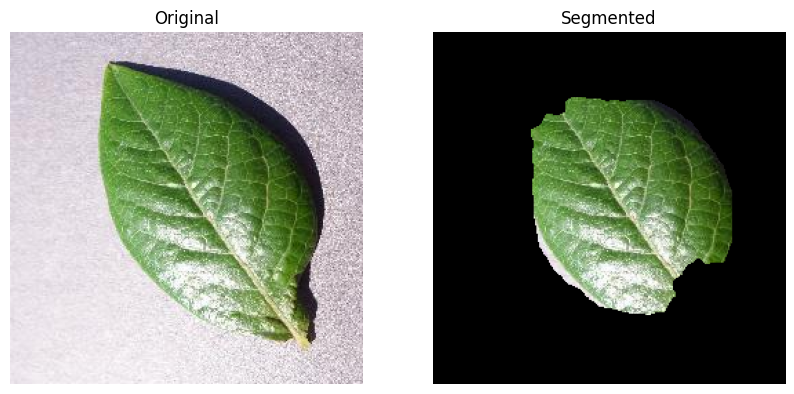

In [81]:
# ---------- Show Results ----------

plt.figure(figsize=(10,5))

# Original Image
plt.subplot(1,2,1)

plt.imshow(img_rgb)

plt.title("Original")

plt.axis("off")

# Segmented Image
plt.subplot(1,2,2)

plt.imshow(segmented)

plt.title("Segmented")

plt.axis("off")

plt.show()

In [82]:
# ---------- Prepare for Classification ----------

cls_img = cv2.resize(
    segmented,
    (32, 32)
)

cls_img = cls_img / 255.0

cls_img = np.expand_dims(
    cls_img,
    axis=0
)

# ---------- Predict ----------

pred = classifier.predict(cls_img)

# ---------- Result ----------

if pred[0][0] > 0.5:

    result = "Diseased"

else:

    result = "Healthy"

confidence = float(pred[0][0])

print("Prediction:", result)

print("Confidence:", confidence)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
Prediction: Healthy
Confidence: 0.20461972057819366
